In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\google_apps\googleplaystore.csv")

In [38]:
df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [39]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [40]:
df.shape

(10841, 13)

In [41]:
df.Size

0                       19M
1                       14M
2                      8.7M
3                       25M
4                      2.8M
                ...        
10836                   53M
10837                  3.6M
10838                  9.5M
10839    Varies with device
10840                   19M
Name: Size, Length: 10841, dtype: object

In [42]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [44]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [45]:
df.duplicated().sum()

483

In [46]:
df_copy_table = df.copy()

In [47]:
print(f'Удаление дубликатов: {len(df_copy_table)}')
df_copy_table = df_copy_table.drop_duplicates()
print(f'После удаления дубликатов: {len(df_copy_table)}')


Удаление дубликатов: 10841
После удаления дубликатов: 10358


In [48]:
df_copy_table['Rating'] = df_copy_table['Rating'].fillna(df_copy_table['Rating'].mean())

df_copy_table['Type'] = df_copy_table['Type'].fillna(df_copy_table['Type'].mode()[0])

df_copy_table['Content Rating'] = df_copy_table['Content Rating'].fillna(df_copy_table['Content Rating'].mode()[0])

df_copy_table['Current Ver'] = df_copy_table['Current Ver'].fillna(df_copy_table['Current Ver'].mode()[0])

df_copy_table['Android Ver'] = df_copy_table['Android Ver'].fillna(df_copy_table['Android Ver'].mode()[0])

df_copy_table.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [49]:
df_copy_table.loc[df_copy_table['Price'] == 'Everyone', 'Price'] = '0'
df_copy_table =df_copy_table[df_copy_table['Installs'] != 'Free'] 

In [50]:
df_copy_table['Price'] = df_copy_table['Price'].str.replace('$', '').astype(float)
df_copy_table['Installs'] = df_copy_table['Installs'].str.replace(',', '').str.replace('+', '').astype(int)
df_copy_table['Reviews'] = df_copy_table['Reviews'].astype(int)

In [51]:
df_copy_table.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [52]:
df_copy_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          10357 non-null  float64
 3   Reviews         10357 non-null  int32  
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  int32  
 6   Type            10357 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10357 non-null  object 
 12  Android Ver     10357 non-null  object 
dtypes: float64(2), int32(2), object(9)
memory usage: 1.0+ MB


In [53]:
print('Cтатистика по числовым колонкам:')
df_copy_table[['Rating', 'Installs', 'Price']].describe()

Cтатистика по числовым колонкам:


,Rating,Installs,Price
count,10357.000000,1.035700e+04,10357.000000
mean,4.188112,1.415776e+07,1.030800
std,0.484020,8.023955e+07,16.278625
min,1.000000,0.000000e+00,0.000000
25%,4.100000,1.000000e+03,0.000000
50%,4.200000,1.000000e+05,0.000000
75%,4.500000,1.000000e+06,0.000000
max,5.000000,1.000000e+09,400.000000


In [54]:
print('Количество платных и бесплатных приложений:')
df_copy_table['Type'].value_counts()

Количество платных и бесплатных приложений:


Type
Free    9592
Paid     765
Name: count, dtype: int64

In [55]:
print('Процетное соотношение платных  и бесплатных приложений: ')
print(f"Free apps: {len(df_copy_table[df_copy_table['Type'] == 'Free'])/len(df_copy_table)*100:.2f}%")
print(f"Paid apps: {len(df_copy_table[df_copy_table['Type'] == 'Paid'])/len(df_copy_table)*100:.2f}%")

Процетное соотношение платных  и бесплатных приложений: 
Free apps: 92.61%
Paid apps: 7.39%


In [56]:
print('Топ 10 категорий по количеству приложений: ')
df_copy_table['Category'].value_counts().head(10)

Топ 10 категорий по количеству приложений: 


Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

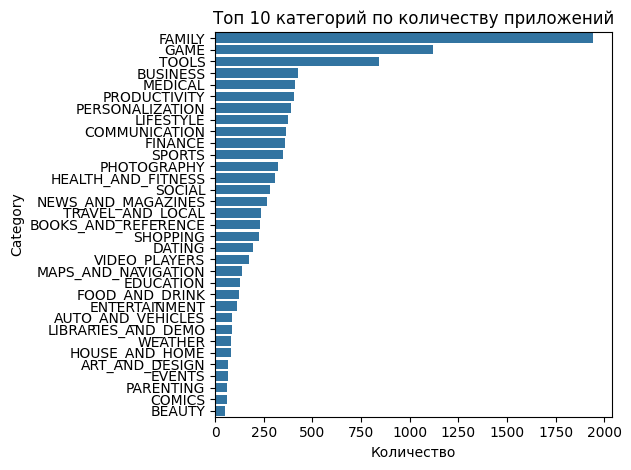

In [57]:
plt.Figure(figsize=(15, 10))
sns.barplot(x=df_copy_table['Category'].value_counts().values, y=df_copy_table['Category'].value_counts().index)
plt.title('Топ 10 категорий по количеству приложений')
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

In [58]:
print('Топ 10 категорий по среднему рейтингу: ')
df_cat_rating = df_copy_table.groupby('Category')['Rating'].mean().sort_values(ascending=False)
df_cat_rating.head(10)

Топ 10 категорий по среднему рейтингу: 


Category
EDUCATION              4.374535
EVENTS                 4.362520
ART_AND_DESIGN         4.350287
BOOKS_AND_REFERENCE    4.311068
PERSONALIZATION        4.304856
PARENTING              4.281590
GAME                   4.277438
BEAUTY                 4.260094
HEALTH_AND_FITNESS     4.251111
SOCIAL                 4.246513
Name: Rating, dtype: float64

C:\Users\79276\AppData\Local\Temp\ipykernel_31240\3854889458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_cat_rating.values, y=df_cat_rating.index, palette='plasma')


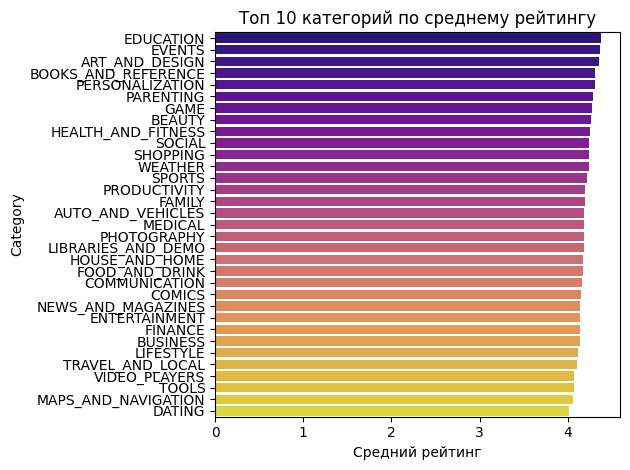

In [59]:
plt.Figure(figsize=(15,10))
sns.barplot(x=df_cat_rating.values, y=df_cat_rating.index, palette='plasma')
plt.title('Топ 10 категорий по среднему рейтингу')
plt.xlabel('Средний рейтинг')
plt.tight_layout()
plt.show()

In [60]:
print('Статистика по рейтингу: ')
df_copy_table['Rating'].describe()

Статистика по рейтингу: 


count    10357.000000
mean         4.188112
std          0.484020
min          1.000000
25%          4.100000
50%          4.200000
75%          4.500000
max          5.000000
Name: Rating, dtype: float64

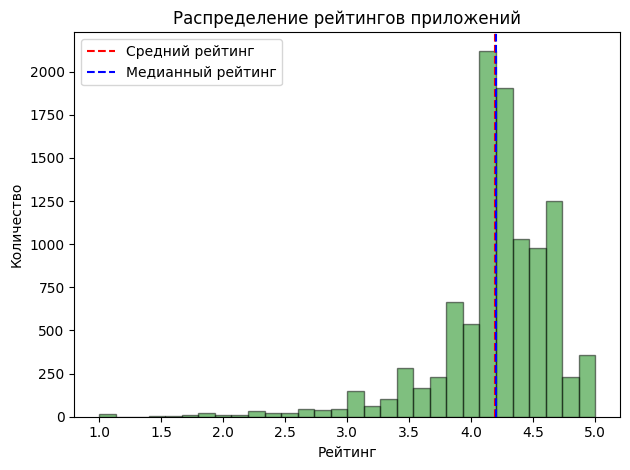

In [61]:
plt.Figure(figsize=(15, 15))
plt.hist(df_copy_table['Rating'], bins=30, color='green', edgecolor='black', alpha=0.5)
plt.title('Распределение рейтингов приложений')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.axvline(df_copy_table['Rating'].mean(), color='red', linestyle='--', label='Средний рейтинг')
plt.axvline(df_copy_table['Rating'].median(), color='blue', linestyle='--', label='Медианный рейтинг')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
print("Распределение рейтингов в топ-5 категориях")

top_5_categories = df_copy_table['Category'].value_counts().head(5).index
print("Топ-5 категорий:", list(top_5_categories))

Распределение рейтингов в топ-5 категориях
Топ-5 категорий: ['FAMILY', 'GAME', 'TOOLS', 'BUSINESS', 'MEDICAL']


C:\Users\79276\AppData\Local\Temp\ipykernel_31240\841525563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Rating', data=df_copy_table[df_copy_table['Category'].isin(top_5_categories)], palette='Set3')


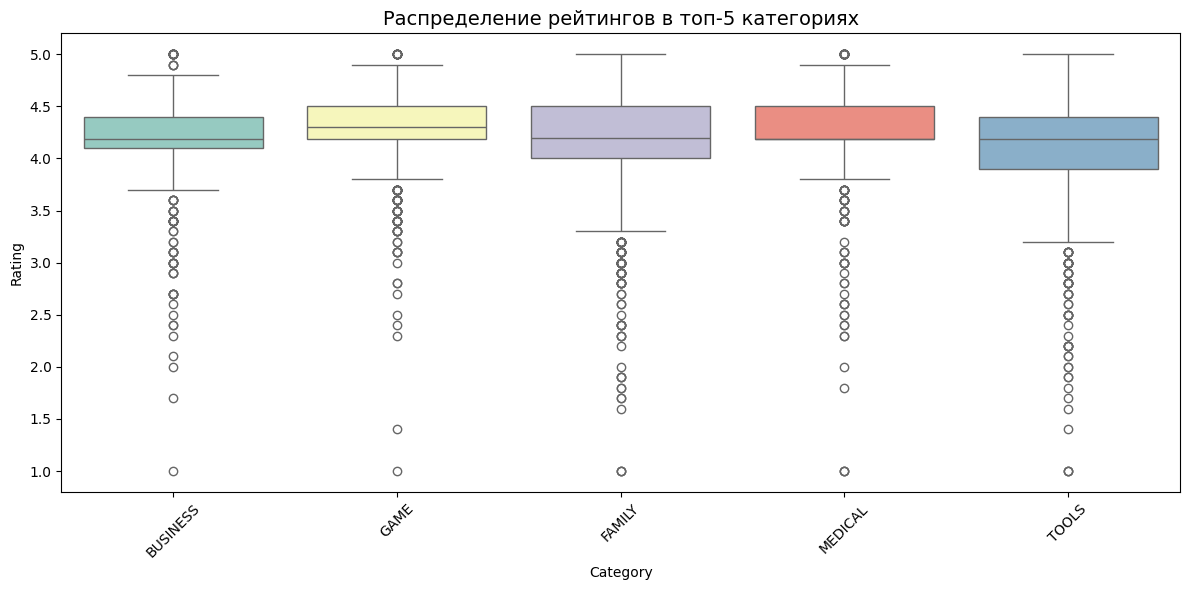

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Rating', data=df_copy_table[df_copy_table['Category'].isin(top_5_categories)], palette='Set3')
plt.title('Распределение рейтингов в топ-5 категориях', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
print("\nСтатистика по категориям:")
for category in top_5_categories:
    data = df_copy_table[df_copy_table['Category'] == category]['Rating']
    print(f"\n{category}:")
    print(f"  Средний: {data.mean():.2f}")
    print(f"  Медиана: {data.median():.2f}")
    print(f"  Мин-Макс: {data.min():.2f} - {data.max():.2f}")


Статистика по категориям:

FAMILY:
  Средний: 4.19
  Медиана: 4.20
  Мин-Макс: 1.00 - 5.00

GAME:
  Средний: 4.28
  Медиана: 4.30
  Мин-Макс: 1.00 - 5.00

TOOLS:
  Средний: 4.07
  Медиана: 4.19
  Мин-Макс: 1.00 - 5.00

BUSINESS:
  Средний: 4.13
  Медиана: 4.19
  Мин-Макс: 1.00 - 5.00

MEDICAL:
  Средний: 4.18
  Медиана: 4.19
  Мин-Макс: 1.00 - 5.00


In [65]:
print("ТОП-10 приложений по рейтингу")

df_with_reviews = df_copy_table[df_copy_table['Reviews'] >= 1000]
top_rated = df_with_reviews.nlargest(10, 'Rating')[['App', 'Category', 'Rating', 'Reviews']]
print(top_rated)

ТОП-10 приложений по рейтингу
                                                    App             Category  \
55    Tickets SDA 2018 and Exam from the State Traff...    AUTO_AND_VEHICLES   
61                       CDL Practice Test 2018 Edition    AUTO_AND_VEHICLES   
64                DMV Permit Practice Test 2018 Edition    AUTO_AND_VEHICLES   
79                              Tickets + PDA 2018 Exam    AUTO_AND_VEHICLES   
99                       ipsy: Makeup, Beauty, and Tips               BEAUTY   
177            eBoox new: Reader for fb2 epub zip books  BOOKS_AND_REFERENCE   
712      Learn Japanese, Korean, Chinese Offline & Free            EDUCATION   
1258           Lose Belly Fat in 30 Days - Flat Stomach   HEALTH_AND_FITNESS   
1260                  Six Pack in 30 Days - Abs Workout   HEALTH_AND_FITNESS   
1307  StrongLifts 5x5 Workout Gym Log & Personal Tra...   HEALTH_AND_FITNESS   

      Rating  Reviews  
55       4.9    10479  
61       4.9     7774  
64       4.9     

In [ ]:
print("ТОП-10 приложений по количеству загрузок")

top_installs = df_copy_table.nlargest(10, 'Installs')[['App', 'Category', 'Installs', 'Rating']]
print(top_installs)

ТОП-10 приложений по количеству загрузок
                                          App             Category  \
152                         Google Play Books  BOOKS_AND_REFERENCE   
335  Messenger – Text and Video Chat for Free        COMMUNICATION   
336                        WhatsApp Messenger        COMMUNICATION   
338              Google Chrome: Fast & Secure        COMMUNICATION   
340                                     Gmail        COMMUNICATION   
341                                  Hangouts        COMMUNICATION   
382  Messenger – Text and Video Chat for Free        COMMUNICATION   
386                                  Hangouts        COMMUNICATION   
391             Skype - free IM & video calls        COMMUNICATION   
411              Google Chrome: Fast & Secure        COMMUNICATION   

       Installs  Rating  
152  1000000000     3.9  
335  1000000000     4.0  
336  1000000000     4.4  
338  1000000000     4.3  
340  1000000000     4.3  
341  1000000000     4.0  
382  1

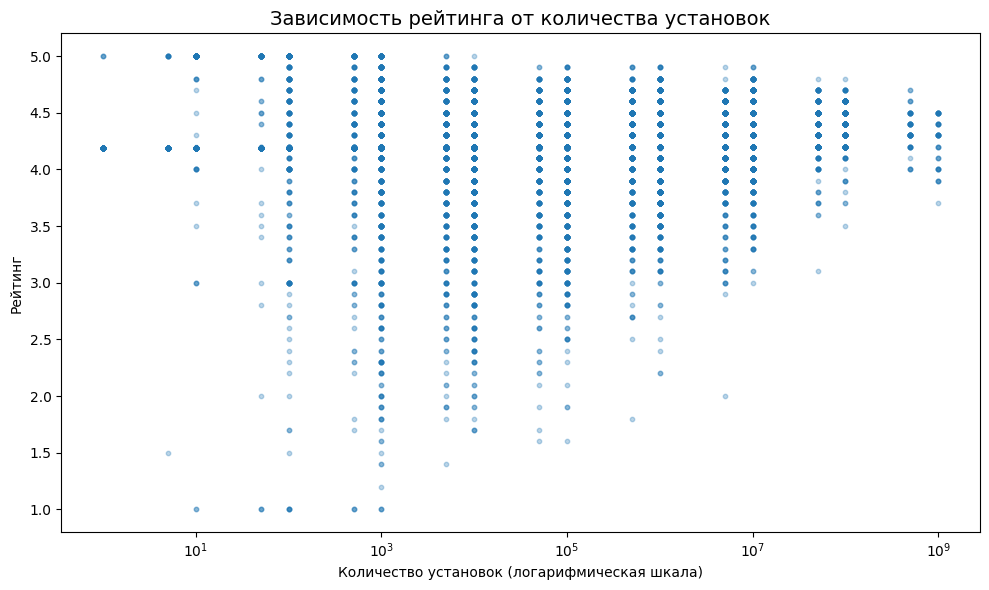

In [73]:
plt.figure(figsize=(10, 6))
plt.scatter(df_copy_table['Installs'], df_copy_table['Rating'], alpha=0.3, s=10)
plt.xscale('log')
plt.title('Зависимость рейтинга от количества установок', fontsize=14)
plt.xlabel('Количество установок (логарифмическая шкала)')
plt.ylabel('Рейтинг')
plt.tight_layout()
plt.show()

In [74]:
correlation = df_copy_table['Rating'].corr(df_copy_table['Installs'])
print(f"\nКорреляция между рейтингом и установками: {correlation:.3f}")

if correlation > 0.3:
    print("Слабая положительная связь — с ростом установок рейтинг немного растет")
elif correlation > 0.7:
    print("Сильная положительная связь — чем больше установок, тем выше рейтинг")
else:
    print("Связь очень слабая или отсутствует")


Корреляция между рейтингом и установками: 0.051
Связь очень слабая или отсутствует


In [76]:
numeric_cols = ['Rating', 'Reviews', 'Installs', 'Price']
correlation = df_copy_table[numeric_cols].corr()['Rating'].sort_values(ascending=False)
print("Корреляция с рейтингом:")
print(correlation)

Корреляция с рейтингом:
Rating      1.000000
Reviews     0.068530
Installs    0.050669
Price      -0.020587
Name: Rating, dtype: float64


C:\Users\79276\AppData\Local\Temp\ipykernel_31240\3186206493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.index, y=correlation.values, palette='coolwarm')


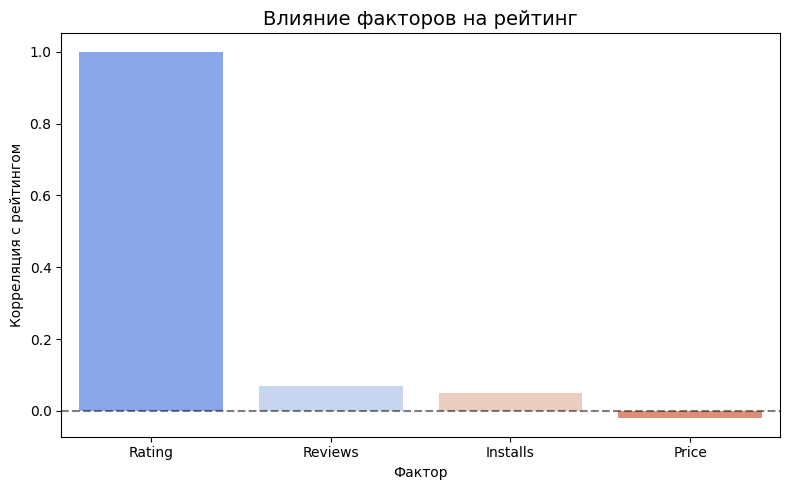

In [77]:
plt.figure(figsize=(8, 5))
sns.barplot(x=correlation.index, y=correlation.values, palette='coolwarm')
plt.title('Влияние факторов на рейтинг', fontsize=14)
plt.xlabel('Фактор')
plt.ylabel('Корреляция с рейтингом')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [79]:
# 1. Самая популярная категория
top_category = df_copy_table['Category'].value_counts().index[0]
print(f"1. Самая популярная категория: {top_category}")

# 2. Категория с лучшим рейтингом
best_rating_cat = df_copy_table.groupby('Category')['Rating'].mean().idxmax()
print(f"2. Категория с лучшим средним рейтингом: {best_rating_cat}")

# 3. Самое популярное приложение
top_app = df_copy_table.nlargest(1, 'Installs')['App'].values[0]
print(f"3. Самое популярное приложение: {top_app}")

# 4. Связь рейтинга и установок
corr = df_copy_table['Rating'].corr(df_copy_table['Installs'])
print(f"4. Связь рейтинга и установок: {corr:.3f}")

# 5. Платные vs бесплатные
paid_rating = df_copy_table[df_copy_table['Price'] > 0]['Rating'].mean()
free_rating = df_copy_table[df_copy_table['Price'] == 0]['Rating'].mean()
print(f"5. Платные приложения имеют рейтинг {paid_rating:.2f}, бесплатные - {free_rating:.2f}")

1. Самая популярная категория: FAMILY
2. Категория с лучшим средним рейтингом: EDUCATION
3. Самое популярное приложение: Google Play Books
4. Связь рейтинга и установок: 0.051
5. Платные приложения имеют рейтинг 4.25, бесплатные - 4.18


In [81]:
df_copy_table.to_csv('google_play_store_cleaned.csv', index=False)
print("Данные сохранены в google_play_store_cleaned.csv")

Данные сохранены в google_play_store_cleaned.csv
